In [1]:
!curl -sL https://github.com/srush/Tensor-Puzzles/raw/main/lib.py -o lib.py

In [1]:
import torch
from lib import draw_examples, make_test, run_test
import numpy as np
from torchtyping import TensorType as TT
tensor = torch.tensor

In [2]:
# Allowed base functions

def arange(i: int):
    "Use this function to replace a for-loop."
    return torch.tensor(range(i))

def where(q, a, b):
    "Use this function to replace an if-statement."
    return (q * a) + (~q) * b

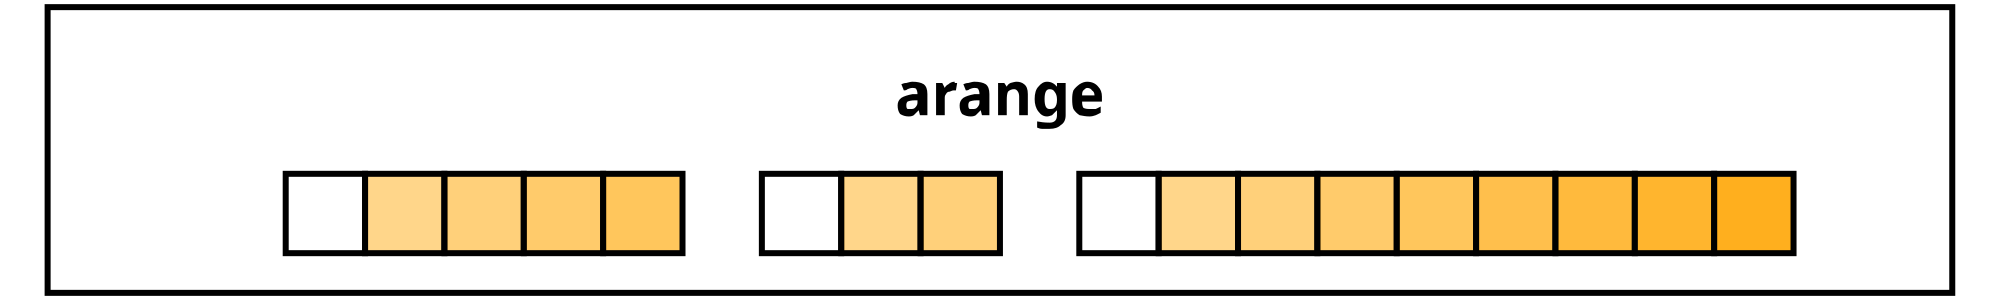

In [3]:
# Examples

draw_examples("arange", [{"" : arange(i)} for i in [5, 3, 9]])

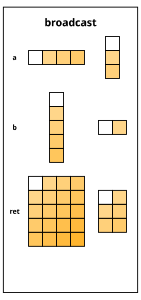

In [4]:
examples = [(arange(4), arange(5)[:, None]) ,
            (arange(3)[:, None], arange(2))]
draw_examples("broadcast", [{"a": a, "b":b, "ret": a + b} for a, b in examples])

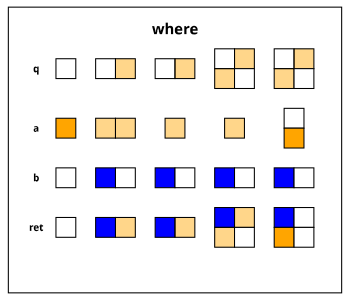

In [5]:
# In diagrams, orange is positive/True, white is zero/False, and blue is negative.
# If q is white -> take b value. If q is orange -> take a value.

examples = [(tensor([False]), tensor([10]), tensor([0])),
            (tensor([False, True]), tensor([1, 1]), tensor([-10, 0])),
            (tensor([False, True]), tensor([1]), tensor([-10, 0])),
            (tensor([[False, True], [True, False]]), tensor([1]), tensor([-10, 0])),
            (tensor([[False, True], [True, False]]), tensor([[0], [10]]), tensor([-10, 0])),
           ]
draw_examples("where", [{"q": q, "a":a, "b":b, "ret": where(q, a, b)} for q, a, b in examples])

## Rules

1. These puzzles are about broadcasting
2. Each puzzle needs to be solved in 1 line (<80 columns) of code.
3. You are allowed @, arithmetic, comparison, shape, any indexing (e.g. a[:j], a[:, None], a[arange(10)]), and previous puzzle functions.
4. You are not allowed anything else. No view, sum, take, squeeze, tensor.
5. You can use arange and where

## Puzzle 1 - ones. Compute vector of all ones

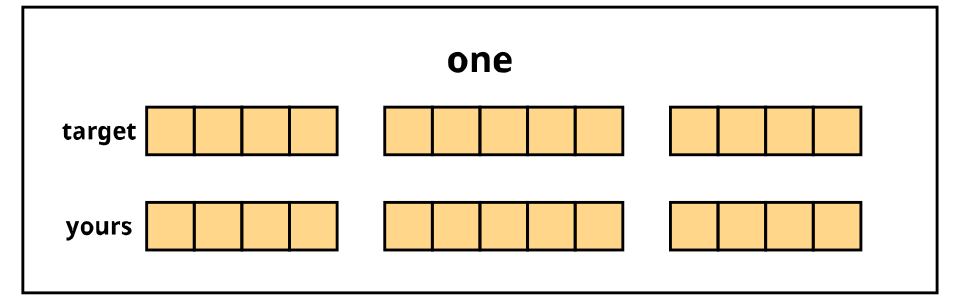

Correct!


In [6]:
def ones_spec(out):
    for i in range(len(out)):
        out[i] = 1

# Note ~(x) = -1-x
def ones(i: int) -> TT["i"]:
    return (arange(i) + (~arange(i))) * -1
    #return where(arange(i) > -1, 1, 0)

test_ones = make_test("one", ones, ones_spec, add_sizes=["i"])
run_test(test_ones)

## Puzzle 2 - sum. Compute sum of a vector

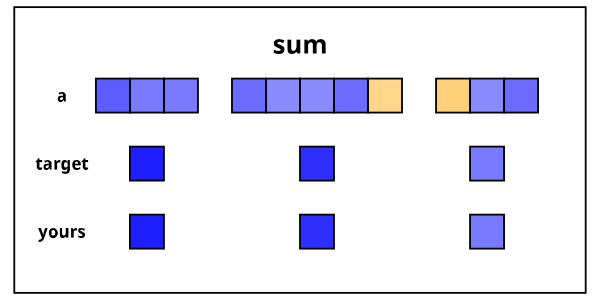

Correct!


In [7]:
def sum_spec(a, out):
    out[0] = 0
    for i in range(len(a)):
        out[0] += a[i]
        
def sum(a: TT["i"]) -> TT[1]:
    # The None slice adds a new axis of size 1 at that position
    return (a @ ones(a.shape[0]))[None]


test_sum = make_test("sum", sum, sum_spec)
run_test(test_sum)

## Puzzle 3 - outer. Compute the outer product of two vectors

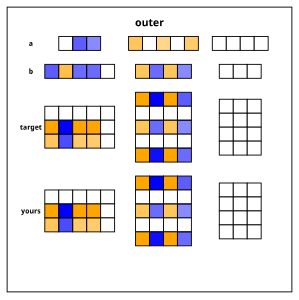

Correct!


In [8]:
def outer_spec(a, b, out):
    for i in range(len(out)):
        for j in range(len(out[0])):
            out[i][j] = a[i] * b[j]
            
def outer(a: TT["i"], b: TT["j"]) -> TT["i", "j"]:
    # b[None, :] converts to [1 * 10]
    # a[:, None] converts to [10 * 1]
    # starting at [10] shaped tensors
    return b[None, :] * a[:, None]
    
test_outer = make_test("outer", outer, outer_spec)
run_test(test_outer)

## Puzzle 4 - diag. Compute the diagonal of a square matrix

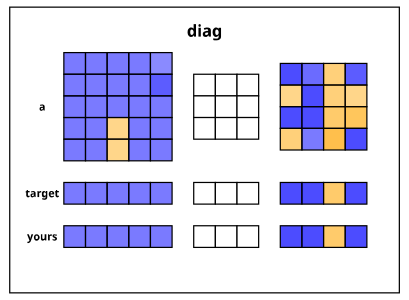

Correct!


In [9]:
def diag_spec(a, out):
    for i in range(len(a)):
        out[i] = a[i][i]
        
def diag(a: TT["i", "i"]) -> TT["i"]:
    return a[arange(a.shape[0]), arange(a.shape[0])]


test_diag = make_test("diag", diag, diag_spec)
run_test(test_diag)

## Puzzle 5 - eye. Compute eye - the identity matrix

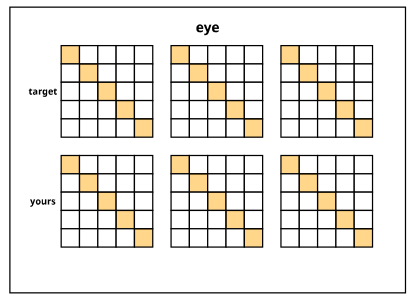

Correct!


In [10]:
def eye_spec(out):
    for i in range(len(out)):
        out[i][i] = 1
        
def eye(j: int) -> TT["j", "j"]:
    # Start utilising comparisons
    return where(arange(j)[:, None] == arange(j)[None, :], ones(j), ones(j)-1) 
    
test_eye = make_test("eye", eye, eye_spec, add_sizes=["j"])
run_test(test_eye)

## Puzzle 6 - triu. Compute upper triangular matrix

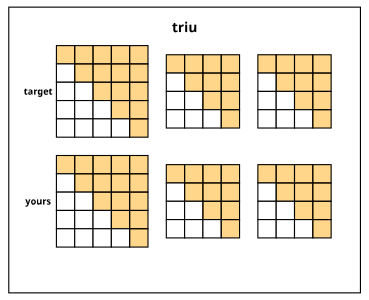

Correct!


In [11]:
def triu_spec(out):
    for i in range(len(out)):
        for j in range(len(out)):
            if i <= j:
                out[i][j] = 1
            else:
                out[i][j] = 0
                
def triu(j: int) -> TT["j", "j"]:
    return where(arange(j)[:, None] <= arange(j)[None, :], ones(j), ones(j)-1) 


test_triu = make_test("triu", triu, triu_spec, add_sizes=["j"])
run_test(test_triu)

## Puzzle 7 - cumsum. Compute cumsum of a vector

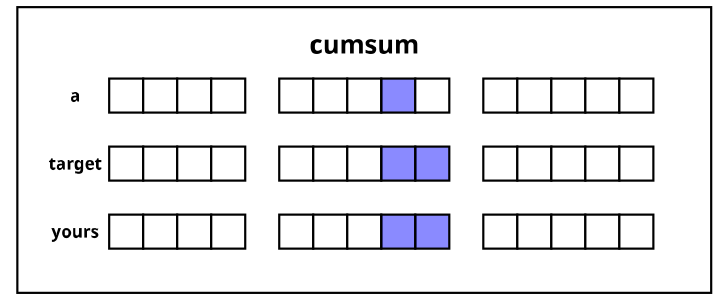

Correct!


In [12]:
def cumsum_spec(a, out):
    total = 0
    for i in range(len(out)):
        out[i] = total + a[i]
        total += a[i]

def cumsum(a: TT["i"]) -> TT["i"]:
    return a @ triu(a.shape[0])

test_cumsum = make_test("cumsum", cumsum, cumsum_spec)
run_test(test_cumsum)

## Puzzle 8 - diff. Compute running difference

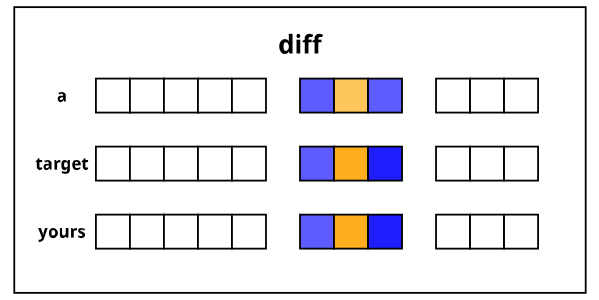

Correct!


In [13]:
def diff_spec(a, out):
    out[0] = a[0]
    for i in range(1, len(out)):
        out[i] = a[i] - a[i - 1]

def diff_old(a: TT["i"], i: int) -> TT["i"]:
    b2 = where(arange(i) > 0, arange(i) - 1, 0)
    return where(arange(i) > 0, a - a[b2], a[b2])

def diff(a: TT["i"], i: int) -> TT["i"]:
    return a - where(arange(i) > 0, a[arange(i)-1], 0)

test_diff = make_test("diff", diff, diff_spec, add_sizes=["i"])
run_test(test_diff)

## Puzzle 9 - Vstack of two vectors

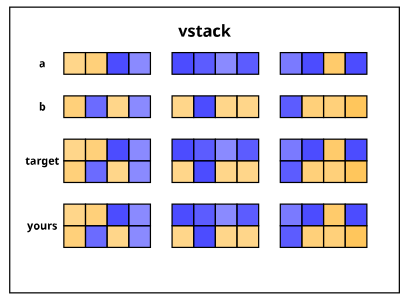

Correct!


In [14]:
def vstack_spec(a, b, out):
    for i in range(len(out[0])):
        out[0][i] = a[i]
        out[1][i] = b[i]

def vstack(a: TT["i"], b: TT["i"]) -> TT[2, "i"]:
    return where((arange(2) == 0)[:, None], a, b)


test_vstack = make_test("vstack", vstack, vstack_spec)
run_test(test_vstack)

## Puzzle 10 - roll. Vector shifted circularly one index to the left

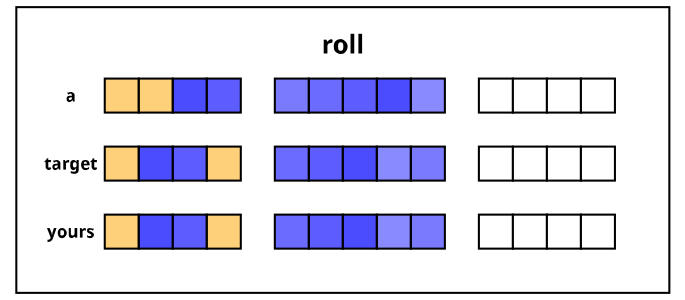

Correct!


In [15]:
def roll_spec(a, out):
    for i in range(len(out)):
        if i + 1 < len(out):
            out[i] = a[i + 1]
        else:
            out[i] = a[i + 1 - len(out)]
            
def roll(a: TT["i"], i: int) -> TT["i"]:
    # can I congest more? exactly 80 cols lol
    return where(arange(i)!=i-1,a[where(arange(i)!=i-1,arange(i)+1,0)],a[ones(i)-1])


test_roll = make_test("roll", roll, roll_spec, add_sizes=["i"])
run_test(test_roll)

## Puzzle 11 - Flip. Flip a vector

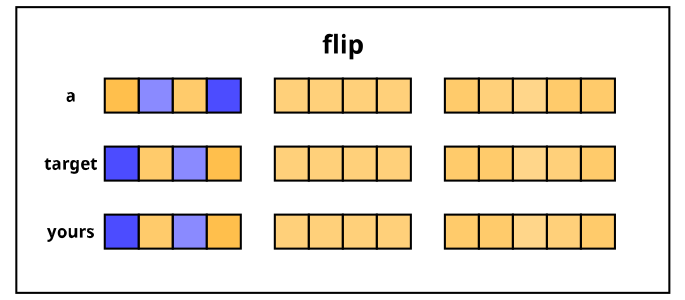

Correct!


In [16]:
def flip_spec(a, out):
    for i in range(len(out)):
        out[i] = a[len(out) - i - 1]
        
def flip(a: TT["i"], i: int) -> TT["i"]:
    return a[a.shape[0] - arange(i) - 1]


test_flip = make_test("flip", flip, flip_spec, add_sizes=["i"])
run_test(test_flip)

## Puzzle 12 - Compress. Keep only masked values (left-aligned)

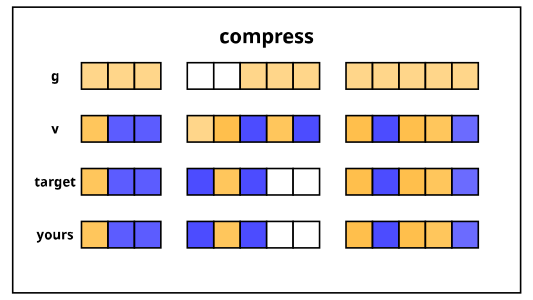

Correct!


In [17]:
def compress_spec(g, v, out):
    j = 0
    for i in range(len(g)):
        if g[i]:
            out[j] = v[i]
            j += 1
            
def compress(g: TT["i", bool], v: TT["i"], i:int) -> TT["i"]:
    return v @ where(g[:, None], arange(i)==(cumsum(g*1)-1)[:, None], 0)


test_compress = make_test("compress", compress, compress_spec, add_sizes=["i"])
run_test(test_compress)

## Puzzle 13 - Pad to. Eliminate or add zeros to change size of vectors

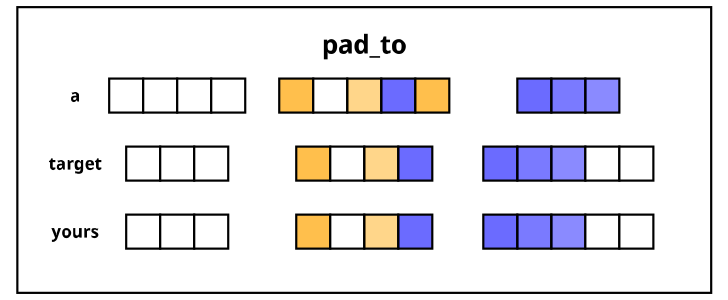

Correct!


In [18]:
def pad_to_spec(a, out):
    for i in range(min(len(out), len(a))):
        out[i] = a[i]


def pad_to(a: TT["i"], i: int, j: int) -> TT["j"]:
    return where(arange(j)[:, None] == arange(i)[None, :], ones(i), ones(i)-1) @ a


test_pad_to = make_test("pad_to", pad_to, pad_to_spec, add_sizes=["i", "j"])
run_test(test_pad_to)

## Puzzle 14 - Sequence_mask - pad out to length per batch

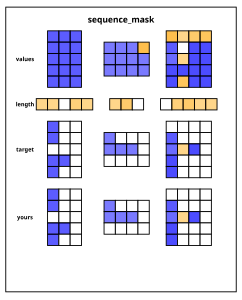

Correct!


In [19]:
def sequence_mask_spec(values, length, out):
    for i in range(len(out)):
        for j in range(len(out[0])):
            if j < length[i]:
                out[i][j] = values[i][j]
            else:
                out[i][j] = 0
    
def sequence_mask(values: TT["i", "j"], length: TT["i", int]) -> TT["i", "j"]:
    return (where(arange(values.shape[1])[None, :] < length[:,None], ones(values.shape[1]), ones(values.shape[1]) - 1)) * values


def constraint_set_length(d):
    d["length"] = d["length"] % d["values"].shape[1]
    return d


test_sequence = make_test("sequence_mask",
    sequence_mask, sequence_mask_spec, constraint=constraint_set_length
)
run_test(test_sequence)

## Puzzle 15 - bincount. Count number of times each entry was seen

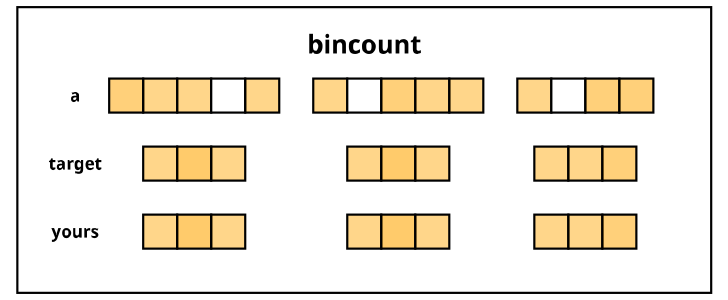

Correct!


In [20]:
def bincount_spec(a, out):
    for i in range(len(a)):
        out[a[i]] += 1
        
def bincount(a: TT["i"], j: int) -> TT["j"]:
    return ones(a.shape[0]) @ where(arange(j)[None,:] == a[:,None], ones(j), ones(j)-1)


def constraint_set_max(d):
    d["a"] = d["a"] % d["return"].shape[0]
    return d


test_bincount = make_test("bincount",
    bincount, bincount_spec, add_sizes=["j"], constraint=constraint_set_max
)
run_test(test_bincount)

## Puzzle 16 - scatter add. Add together values that link to the same location.

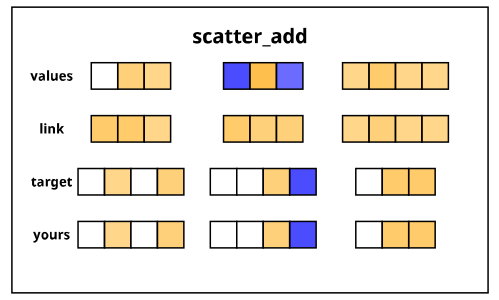

Correct!


In [21]:
def scatter_add_spec(values, link, out):
    for j in range(len(values)):
        out[link[j]] += values[j]
        
def scatter_add(values: TT["i"], link: TT["i"], j: int) -> TT["j"]:
    return values @ where(link[:,None]==arange(j), ones(j), ones(j)-1) 


def constraint_set_max(d):
    d["link"] = d["link"] % d["return"].shape[0]
    return d


test_scatter_add = make_test("scatter_add",
    scatter_add, scatter_add_spec, add_sizes=["j"], constraint=constraint_set_max
)
run_test(test_scatter_add)

## Puzzle 17 - flatten

In [60]:
def flatten_spec(a, out):
    k = 0
    for i in range(len(a)):
        for j in range(len(a[0])):
            out[k] = a[i][j]
            k += 1

# indexing into tensors with tensors - remember rules
def flatten(a: TT["i", "j"], i:int, j:int) -> TT["i * j"]:
    return a[(cumsum(ones(i*j)) - 1)//j,(cumsum(ones(i*j)) - 1)%j]

test_flatten = make_test("flatten", flatten, flatten_spec, add_sizes=["i", "j"])
run_test(test_flatten)

Correct!


## Puzzle 18 - linspace

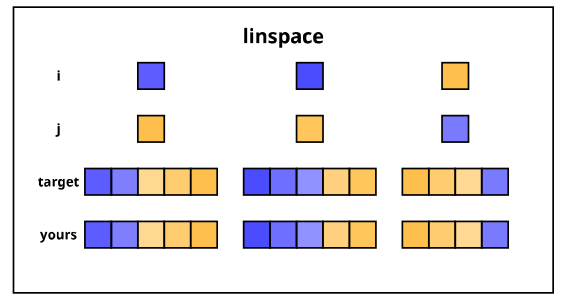

Correct!


In [98]:
def linspace_spec(i, j, out):
    for k in range(len(out)):
        out[k] = float(i.item() + (j.item() - i.item()) * k / max(1, len(out) - 1))


def linspace(i: TT[1], j: TT[1], n: int) -> TT["n", float]:
    return i + (j-i)*arange(n) / max(1, n-1)

test_linspace = make_test("linspace", linspace, linspace_spec, add_sizes=["n"])
run_test(test_linspace)

## Puzzle 19 - Heaviside

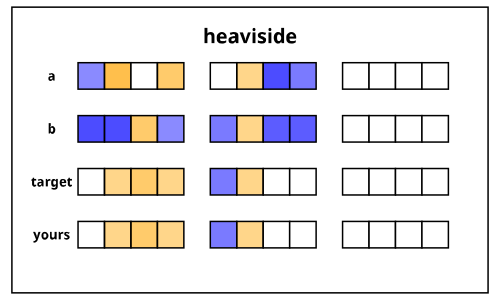

Correct!


In [104]:
def heaviside_spec(a, b, out):
    for k in range(len(out)):
        if a[k] == 0:
            out[k] = b[k]
        else:
            out[k] = int(a[k] > 0)

def heaviside(a: TT["i"], b: TT["i"]) -> TT["i"]:
    return where(a == 0, b, where(a > 0, 1, 0))

test_heaviside = make_test("heaviside", heaviside, heaviside_spec)
run_test(test_heaviside)

## Puzzle 20 - repeat (1d)

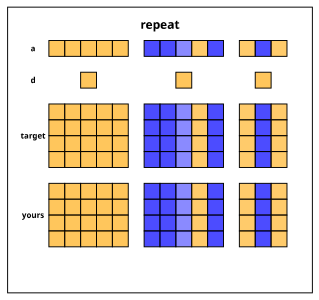

Correct!


In [115]:
def repeat_spec(a, d, out):
    for i in range(d[0]):
        for k in range(len(a)):
            out[i][k] = a[k]

def constraint_set(d):
    d["d"][0] = d["return"].shape[0]
    return d

            
def repeat(a: TT["i"], d: TT[1]) -> TT["d", "i"]:
    return ones(d)[:,None] @ a[None, :]

test_repeat = make_test("repeat", repeat, repeat_spec, constraint=constraint_set)
run_test(test_repeat)

## Puzzle 21 - Bucketise

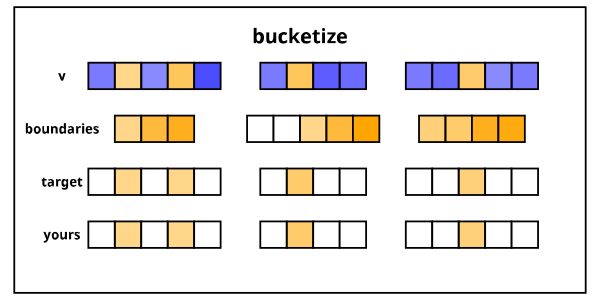

Correct!


In [132]:
def bucketize_spec(v, boundaries, out):
    for i, val in enumerate(v):
        out[i] = 0
        for j in range(len(boundaries)-1):
            if val >= boundaries[j]:
                out[i] = j + 1
        if val >= boundaries[-1]:
            out[i] = len(boundaries)


def constraint_set(d):
    d["boundaries"] = np.abs(d["boundaries"]).cumsum()
    return d

            
def bucketize(v: TT["i"], boundaries: TT["j"]) -> TT["i"]:
    return (1 * (v[:, None] >= boundaries)) @ ones(boundaries.shape[0])

test_bucketize = make_test("bucketize", bucketize, bucketize_spec,
                           constraint=constraint_set)
run_test(test_bucketize)